In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import classification_report
import pandas as pd
import requests
import re
import numpy as np
import warnings
import os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')


def get_answers(text):
    if re.fullmatch("\d\d?", text):
        matches = re.findall("\d\d?", text)
    elif re.fullmatch("[\d\d?, ]+", text):
        matches = re.findall("\d\d?", text)
    else:
        matches = re.findall("\d\d?", text)[-1:]
    return [int(m) for m in matches if int(m) < 15]



def default_evaluation(true_labels, pred_labels):
    result = dict()
    result['precision'] = precision_score(true_labels, pred_labels)
    result['recall'] = recall_score(true_labels, pred_labels)
    result['f1'] = f1_score(true_labels, pred_labels)
    result['accuracy'] = accuracy_score(true_labels, pred_labels)
    return result


def get_sampled_results(preds, df, report=False, include_pop=False):
    new_df = {"sample_id": [], "questionEntityId":[],"prediction": []}
    if include_pop:
        new_df["popularity"] = []

    for _, row in preds.iterrows():
        for _, id in row['match_dict'].items():
            new_df["sample_id"].append(id)
            new_df["prediction"].append(id in row['prediction_sample_id'])
            new_df["questionEntityId"].append(row['questionEntityId'])
            if include_pop:
                # print(type(row["popularity"]))
                new_df["popularity"].append(row["popularity"][0] if type(row["popularity"]) == list else row["popularity"])

    result = pd.DataFrame(data=new_df)
    result = result.sort_values(by=["sample_id"]).reset_index(drop=True)
    result.prediction = result.prediction.astype(np.int32)
    all_sample_ids = set(result["sample_id"].values.tolist())
    df = df[df.sample_id.apply(lambda x: x in all_sample_ids)].sort_values(by=["sample_id"])
    result["correct"] = df['correct'].astype(np.int32).values
    # if include_pop:
        # result["popularity"] = result.sample_id.apply(lambda x: sample2pop(df, x))
    
    if report:
        true_labels = df['correct'].astype(np.int32).values
        pred_labels = result['prediction'].astype(np.int32).values
        print(classification_report(pred_labels, true_labels))
        metrics = default_evaluation(true_labels, pred_labels)
        print(metrics)
        return result, metrics
    
    return result


key = ''
def wikimedia_pagereviews(label, start_data="20230101", end_date="20230901"):
    label = label[0].upper() + label[1:]
    if '/' in label:
        test_lbl = label.replace('/', '%2F')
    elif '?' in label:
        test_lbl = label.replace('?', '%3F')
    else:
        test_lbl = '_'.join(label.split(' '))
        
    url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/"
    url += f"{test_lbl}/monthly/{start_data}/{end_date}"
    headers = {
        'accept': 'application/json',
        'Authorization': key,
        'User-Agent': '2368ba8df0e5f6b69af8027312c507c654c234c8'
    }

    response = requests.get(
        url = url,
        headers=headers,
    )   
    print(url)
    
    return response.json()['items'][0]['views']

def sample2wiki_id(df, sample_id):
    sample_id = int(sample_id)
    return df[df['sample_id'] == sample_id]['answerEntityId'].values[0]

def sample2wiki(df, sample_id):
    sample_id = int(sample_id)
    return df[df['sample_id'] == sample_id]['answerEntity'].values[0]

def sample2pop(df, sample_id):
    sample_id = int(sample_id)
    answer_id = sample2wiki_id(df, sample_id)
    pop = views[views['answerEntityId'] == answer_id]['views'].values
    return pop[0] if len(pop) > 0 else -1

def index2sample(match_dict, idx):
    return match_dict[idx]




def popularity(df, raw):
    res = []
    for token in raw['top_token']:
        try:
            sample_id = index2sample(raw['match_dict'], token)
        except:
            continue
        try:
            wiki_id = sample2wiki_id(df, sample_id)
            val = views[views['answerEntityId'] == wiki_id]['views'].values
        except:
            wiki = sample2wiki(df, sample_id)
            val = views[views['answerEntity'] == wiki]['views'].values
        if val:
            res.append(val[0])
    return sum(res) / len(res) if res else -1


def init_preds(preds, multi=False, first=False):
    preds['prediction'][preds['prediction'].isna()] = "None"
    preds['raw_prediction'] = preds["prediction"]
    preds['match_dict'] = preds['match_dict'].apply(eval)
    preds['top_token'] = preds['raw_prediction'].apply(get_answers)
    preds['popularity'] = [popularity(df, row) for i, row in preds.iterrows()]
    preds['popularity'] = [popularity(df, row) for i, row in preds.iterrows()]
    preds['prediction_sample_id'] = preds.apply(lambda row: [index2sample(row["match_dict"], int(token)) for token in row["top_token"] if int(token) in row["match_dict"]], axis=1)

In [48]:
train_file_path = "../TextGraphs17-shared-task/data/tsv/train.tsv"
file_ws = '../analysis/llama_8B_train_sample_ds_ws_probs.tsv'
file_ds = '../analysis/llama_8B_train_sample_ds_probs.tsv'

df = pd.read_csv(train_file_path, sep="\t")
views = pd.read_csv("views_v2.csv")

df_ws = pd.read_csv(file_ws, sep='\t')
init_preds(df_ws)

df_ds = pd.read_csv(file_ds, sep='\t')
init_preds(df_ds)

In [49]:
an_dir = "../analysis/"
all_files = os.listdir(an_dir)
data = {}

for file in all_files:
    print(f"Loading {file}")
    name = file.split(".")[0]
    filepath = os.path.join(an_dir, file)
    df_ = pd.read_csv(filepath, sep='\t')
    init_preds(df_)
    data[name] = df_

Loading llama_70B_train_sample_ds_probs.tsv
Loading llama_70B_train_sample_ds_tg_probs.tsv
Loading llama_70B_train_sample_ds_tg_ws_probs.tsv
Loading llama_70B_train_sample_ds_ws_probs.tsv
Loading llama_8B_train_sample_ds_probs.tsv
Loading llama_8B_train_sample_ds_tg_probs.tsv
Loading llama_8B_train_sample_ds_tg_ws_probs.tsv
Loading llama_8B_train_sample_ds_ws_probs.tsv


In [50]:
top_questions = 100

predictions = {}

for name, df_ in data.items():
    df_preds = get_sampled_results(df_, df, report=False, include_pop=True)
    predictions[name] = df_preds
    df_preds = df_preds[df_preds.popularity != -1].sort_values("popularity", ascending=False).reset_index(drop=True)
    print(f"-----------{name} top {top_questions}----------------")
    df_slice = df_preds.groupby("questionEntityId").head(top_questions)
    metrics = default_evaluation(df_slice["prediction"], df_slice["correct"])
    for k, v in metrics.items():
        print(f"{k}: {v}")
    print(f"-----------{name} tail {top_questions}----------------")
    df_slice = df_preds.groupby("questionEntityId").tail(top_questions)
    metrics = default_evaluation(df_slice["prediction"], df_slice["correct"])
    for k, v in metrics.items():
        print(f"{k}: {v}")
    print("\n\n")

-----------llama_70B_train_sample_ds_probs top 100----------------
precision: 0.7302371541501976
recall: 0.7563971340839304
f1: 0.743086978381096
accuracy: 0.9506947124662293
-----------llama_70B_train_sample_ds_probs tail 100----------------
precision: 0.727810650887574
recall: 0.7561475409836066
f1: 0.7417085427135678
accuracy: 0.9504052489386338



-----------llama_70B_train_sample_ds_tg_probs top 100----------------
precision: 0.7185332011892963
recall: 0.7474226804123711
f1: 0.7326932794340576
accuracy: 0.9488048001548437
-----------llama_70B_train_sample_ds_tg_probs tail 100----------------
precision: 0.7166831194471865
recall: 0.7476828012358393
f1: 0.7318548387096774
accuracy: 0.9485144682086519



-----------llama_70B_train_sample_ds_tg_ws_probs top 100----------------
precision: 0.7504970178926441
recall: 0.775950668036999
f1: 0.763011622031329
accuracy: 0.9544748592506309
-----------llama_70B_train_sample_ds_tg_ws_probs tail 100----------------
precision: 0.7504970178926441


In [67]:
ds_name = 'llama_70B_train_sample_ds_probs'
ws_name = 'llama_70B_train_sample_ds_ws_probs'

ds_predictions = predictions[ds_name]
ws_predictions = predictions[ws_name]

df_new = pd.DataFrame(
    {
        "ds_prediction": ds_predictions["prediction"],
        "ds_popularity": ds_predictions["popularity"],
        "ws_prediction": ws_predictions["prediction"],
        "ws_popularity": ws_predictions["popularity"],
        "correct": ds_predictions["correct"]
    }
)

df_new["final_prediction"] = df_new.apply(lambda row: row["ds_prediction"] if row["ds_popularity"] > row["ws_popularity"] else row["ws_prediction"], axis=1)

In [68]:
default_evaluation(df_new["correct"], df_new["final_prediction"])

{'precision': np.float64(0.7938856015779092),
 'recall': np.float64(0.7644824311490979),
 'f1': np.float64(0.7789066279632317),
 'accuracy': 0.9575909428359317}

In [59]:
default_evaluation(df_new["correct"], df_new["ds_prediction"])

{'precision': np.float64(0.7564102564102564),
 'recall': np.float64(0.7283950617283951),
 'f1': np.float64(0.7421383647798742),
 'accuracy': 0.9505382331106161}

In [60]:
default_evaluation(df_new["correct"], df_new["ws_prediction"])

{'precision': np.float64(0.8159203980099502),
 'recall': np.float64(0.7787274453941121),
 'f1': np.float64(0.7968901846452867),
 'accuracy': 0.9612100965107646}

In [69]:
df_ds_false = df_new[(df_new.ds_prediction != df_new.correct) & (df_new.ws_prediction == df_new.correct)]
df_ds_true = df_new[(df_new.ds_prediction == df_new.correct) & (df_new.ws_prediction != df_new.correct)]

In [70]:
df_ds_false.ds_popularity.describe()

count    3.330000e+02
mean     1.632438e+05
std      2.717930e+05
min     -1.000000e+00
25%      1.402100e+04
50%      6.721900e+04
75%      1.905710e+05
max      1.804051e+06
Name: ds_popularity, dtype: float64

In [71]:
df_ds_true.ds_popularity.describe()

count    2.180000e+02
mean     1.570474e+05
std      2.615689e+05
min     -1.000000e+00
25%      1.050500e+04
50%      5.728200e+04
75%      1.658410e+05
max      1.804051e+06
Name: ds_popularity, dtype: float64

<Axes: >

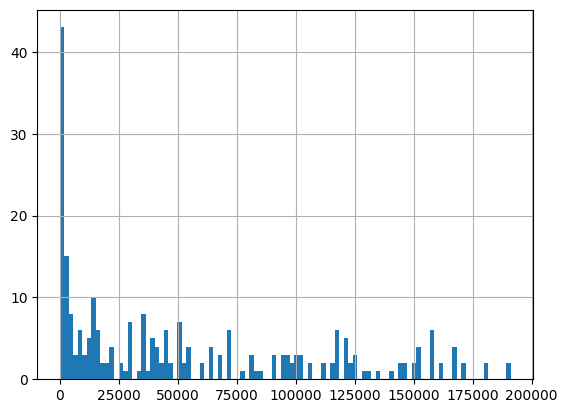

In [62]:
df_ds_false[df_ds_false.ds_popularity < 0.2e6].ds_popularity.hist(bins=100)

<Axes: >

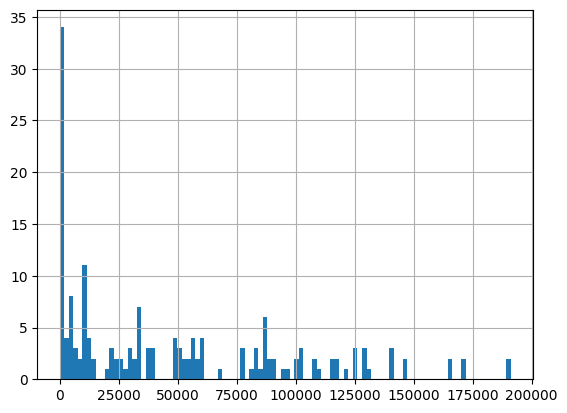

In [63]:
df_ds_true[df_ds_true.ds_popularity < 0.2e6].ds_popularity.hist(bins=100)

In [133]:
views.sort_values("views").head(20)

,Unnamed: 0,answerEntityId,answerEntity,views
518,518,Q18086665,Hoenn Pokédex,1
5356,5356,Q13569737,Their Second Album! Herman's Hermits on Tour,1
1742,1742,Q23643186,War of 1812 Shipwrecks,1
5090,5090,Q75310902,Katharine Seymour,1
3909,3909,Q97738250,presidential inauguration of Joe Biden,1
4354,4354,Q274400,88 Minutes,1
5061,5061,Q59156341,Birds of a Feather...,1
259,259,Q18611720,Innocence + Experience Tour,1
2959,2959,Q3565721,Walter Creighton Brown,1
2863,2863,Q7798571,Thru the Looking Glass,1


# Scrap views

In [10]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from retrying import retry

# Функция для получения данных из Wikimedia с повторной попыткой
@retry(stop_max_attempt_number=5, wait_fixed=1000)
def fetch_data_with_retry(label, start_date="20230101", end_date="20230901"):
    return wikimedia_pagereviews(label, start_date, end_date)

# Основная функция для получения данных из Wikimedia
def wikimedia_pagereviews(label, start_date="20230101", end_date="20230901"):
    label = label[0].upper() + label[1:]
    if '/' in label:
        test_lbl = label.replace('/', '%2F')
    elif '?' in label:
        test_lbl = label.replace('?', '%3F')
    else:
        test_lbl = '_'.join(label.split(' '))
        
    url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/"
    url += f"{test_lbl}/monthly/{start_date}/{end_date}"
    headers = {
        'accept': 'application/json',
        'Authorization': 'key',  # Замените 'key' на ваш ключ API, если требуется
        'User-Agent': '2368ba8df0e5f6b69af8027312c507c654c234c8'
    }

    response = requests.get(url=url, headers=headers)
    
    if response.status_code == 404:
        return -1
    
    if response.status_code != 200:
        response.raise_for_status()  # Для повторной попытки в случае ошибки

    # print(url)
    response = response.json()
    if "items" not in response:
        return -1
    items = response["items"]
    return [items[i]['views'] for i in range(len(items))]

# Обертка для функции с обработкой исключений
def safe_wikimedia_pagereviews(label, start_date="20230101", end_date="20230901"):
    try:
        return fetch_data_with_retry(label, start_date, end_date)
    except Exception as exc:
        print(f"Error fetching data for {label}: {exc}")
        return -1

# Параллельный скраппер
def parallel_scraper(labels, start_date="20230101", end_date="20230901", max_workers=8):
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_label = {executor.submit(safe_wikimedia_pagereviews, label, start_date, end_date): label for label in labels}
        with tqdm(total=len(labels)) as pbar:
            for future in as_completed(future_to_label):
                label = future_to_label[future]
                try:
                    data = future.result()
                    results.append((label, data))
                except Exception as exc:
                    print(f"{label} generated an exception: {exc}")
                    results.append((label, -1))
                pbar.update(1)
    return results


In [6]:
all_answers = set()
all_answer_ids = set()

for match_dict in df_ws["match_dict"]:
    for sample_id in match_dict.values():
        all_answers.add(sample2wiki(sample_id=sample_id, df=df))
        all_answer_ids.add(sample2wiki_id(df=df, sample_id=sample_id))

In [11]:
%%time

results = parallel_scraper(list(all_answers))

  0%|          | 0/6170 [00:00<?, ?it/s]

CPU times: total: 10.1 s
Wall time: 7min 28s


In [12]:
results_ids = parallel_scraper(list(all_answer_ids))

[('Grammy Award for Best Rock Performance',
  [2985, 6136, 2737, 2253, 2335, 2265, 2431, 2294, 77]),
 ('Dean Martin',
  [213956, 179167, 173720, 150517, 160240, 204868, 224768, 213449, 4755]),
 ('Stratford-upon-Avon',
  [32337, 29629, 33603, 33045, 37054, 33635, 33535, 33629, 963]),
 ('Mikhail Gorbachev',
  [188417, 176912, 205331, 198419, 176103, 191214, 176312, 179828, 4913]),
 ('Gondor', [18085, 16264, 17395, 15289, 13365, 12443, 13994, 14794, 457]),
 ('Magnus Mills', [711, 575, 724, 733, 864, 954, 771, 768, 19]),
 ('Ben Affleck',
  [514155, 730870, 590218, 618825, 708461, 518950, 581124, 490412, 12923]),
 ('So You Think You Can Dance',
  [3218, 2570, 2537, 2164, 3395, 2351, 3220, 2971, 84]),
 ("I don't wanna die in an air disaster", -1),
 ('Isfahan', [32557, 27551, 28920, 25307, 25755, 24348, 25353, 26526, 736]),
 ('Weddell seal', [5292, 5050, 6970, 4535, 4015, 4119, 4287, 4607, 156]),
 ('The Curve', [89, 138, 115, 92, 151, 91, 126, 95, 2]),
 ('Mob Rules', [146, 97, 108, 85, 81, 11

In [13]:
results_ids = parallel_scraper(list(all_answer_ids))

  0%|          | 0/6831 [00:00<?, ?it/s]

In [23]:
e2v = {}
id2v = {}

for result in results:
    e2v[result[0]] = result[1]

for result in results_ids:
    id2v[result[0]] = result[1]

In [19]:
df_ws

,questionEntityId,prediction,prob,match_dict,raw_prediction,top_token,popularity,prediction_sample_id
0,Q183484,4,"[{'4': -0.013498109765350819, 'The': -4.763498...","{0: 37634, 1: 37638, 2: 37633, 3: 37632, 4: 37...",4,[4],68050.0,[37639]
1,Q8341,3,"[{'3': -0.7922309041023254, 'The': -1.54223084...","{0: 37619, 1: 37615, 2: 37616, 3: 37617, 4: 37...",3,[3],12041.0,[37617]
2,"Q144622, Q151012",2,"[{'2': -0.0792282298207283, '1': -2.9542281627...","{0: 37602, 1: 37600, 2: 37601, 3: 37606, 4: 37...",2,[2],232572.0,[37601]
3,"Q223374, Q867138",9,"[{'9': -0.40906810760498047, 'The': -2.2840681...","{0: 37585, 1: 37581, 2: 37584, 3: 37589, 4: 37...",9,[9],508.0,[37588]
4,Q1129916,6,"[{'6': -0.9571466445922852, '3': -1.0821466445...","{0: 37570, 1: 37568, 2: 37571, 3: 37572, 4: 37...",6,[6],18656.0,[37573]
...,...,...,...,...,...,...,...,...
995,Q1750699,1,"[{'1': -0.49238723516464233, 'The': -1.6173872...","{0: 88, 1: 93, 2: 95, 3: 91, 4: 92, 5: 89, 6: ...",1,[1],276300.0,[93]
996,"Q19848, Q36153",5,"[{'5': -0.12043792754411697, 'The': -2.6204378...","{0: 69, 1: 66, 2: 65, 3: 72, 4: 74, 5: 67, 6: ...",5,[5],483593.0,[67]
997,"Q121783, Q131364",5,"[{'5': -0.1068989634513855, 'The': -2.73189902...","{0: 57, 1: 56, 2: 63, 3: 60, 4: 55, 5: 58, 6: ...",5,[5],70875.0,[58]
998,"Q1187909, Q54527",1,"[{'1': -0.2468922734260559, '2': -2.6218922138...","{0: 40, 1: 38, 2: 33, 3: 37, 4: 36, 5: 35, 6: ...",1,[1],55639.0,[38]


In [40]:
views = df[(df["answerEntityId"].isin(id2v.keys())) & (df["answerEntity"].isin(e2v.keys()))][["sample_id", "answerEntityId", "answerEntity"]]
views["views_answerEntityId"] = views["answerEntityId"].apply(lambda x: id2v[x] if id2v[x] != -1 else [-1])
views["views_answerEntity"] = views["answerEntity"].apply(lambda x: e2v[x] if e2v[x] != -1 else [-1])
views["views"] = views.apply(lambda row: max(row["views_answerEntity"][0], row["views_answerEntityId"][0]), axis=1)

In [45]:
views.drop_duplicates(["answerEntityId"]).to_csv("views_v2.csv")

In [44]:
views.drop_duplicates(["answerEntityId"])

,sample_id,answerEntityId,answerEntity,views_answerEntityId,views_answerEntity,views
0,0,Q7293530,Ruhollah Khomeini's return to Iran,[-1],"[1757, 2477, 1941, 1807, 1748, 1670, 1454, 146...",1757
1,1,Q5952984,Ruhollah Khomeini's letter to Mikhail Gorbachev,[-1],"[141, 91, 145, 93, 103, 107, 113, 111, 3]",141
2,2,Q38823,Ruhollah Khomeini,[-1],"[104265, 89311, 103841, 89803, 87175, 100559, ...",104265
3,3,Q16045000,Office of the Supreme Leader of Iran,[-1],"[1846, 1314, 1535, 1409, 1364, 1409, 1292, 146...",1846
4,4,Q63195813,Mohammad Reza Pahlavi and Soraya,[-1],[-1],-1
...,...,...,...,...,...,...
37635,37635,Q111522230,Imagination Technologies (United States),[-1],[-1],-1
37636,37636,Q1119662,Imagination Technologies,[-1],"[3910, 3402, 4272, 3549, 3510, 3577, 3873, 380...",3910
37637,37637,Q825762,GeForce,[-1],"[25747, 21040, 23229, 20953, 22320, 21584, 201...",25747
37638,37638,Q477690,CUDA,[-1],"[50685, 50751, 63233, 56840, 63561, 60219, 550...",50685
